In [1]:
import networkx as nx
import numpy as np
rd = np.random
import itertools as it
import knee.rdp as rdp
import knee.kneedle as kneedle

import time

from thresholding import *
from weight_computer import *

from castle.common import GraphDAG, independence_tests
from castle.metrics import MetricsDAG
from castle.algorithms import PC

import matplotlib.pyplot as pl
import pandas as pd
#font = {'size'   : 11}

#import matplotlib
#matplotlib.rc('font', **font)

2024-03-20 14:37:54,010 - /home/filipe/anaconda3/envs/pythenv39/lib/python3.9/site-packages/castle/backend/__init__.py[line:36] - INFO: You can use `os.environ['CASTLE_BACKEND'] = backend` to set the backend(`pytorch` or `mindspore`).
2024-03-20 14:37:54,566 - /home/filipe/anaconda3/envs/pythenv39/lib/python3.9/site-packages/castle/algorithms/__init__.py[line:36] - INFO: You are using ``pytorch`` as the backend.


## NETWORK

In [2]:
df = pd.read_csv("notas-alunos-2012-2022-corrigido.csv")

states = {node:list(df[node].unique()) for node in df.columns}
X = np.array(df)
n_nodes = len(df.columns)
node_list = df.columns
del df

## PC Algorithm

t(s) 615.2476276020001
FPR 0.04308390022675737
FNR 0.17391304347826086
MCC 0.5552336497709424


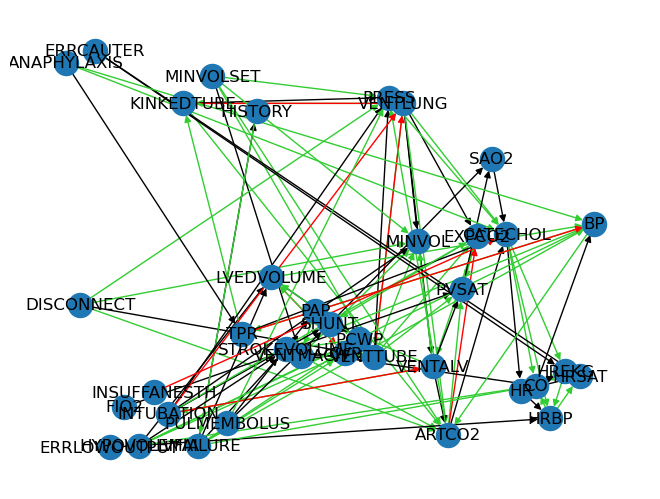

t(s) 251.00024884899995
FPR 0.08064516129032258
FNR 0.06521739130434782
MCC 0.6248614584019484


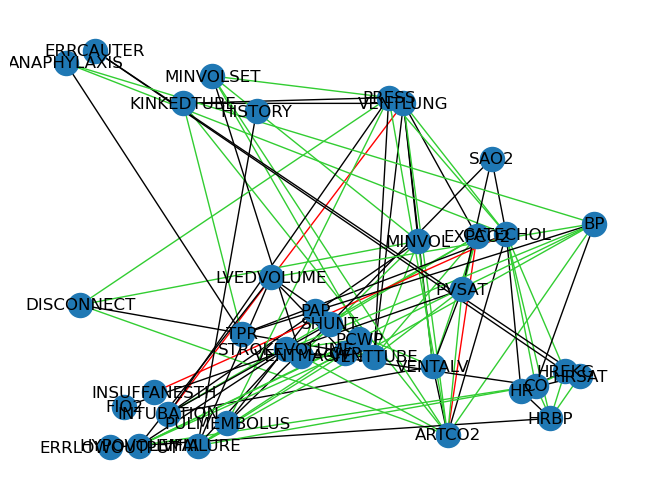

In [3]:
# PC algorithm
pc_time = time.process_time()
pc = PC(alpha=0.05)
pc.learn(a)
pc_time = time.process_time() - pc_time

FN = int(np.sum((true_matrix-pc.causal_matrix)>0)) #False Negatives
FP = int(np.sum((true_matrix-pc.causal_matrix)<0)) #False Positives
TP = len(DAGt.edges) - FN #True Positives = P - FN
TN = (n_nodes*n_nodes - len(DAGt.edges))-FP #True Negatives = N-FP

print("t(s)", pc_time)

print("FPR", FP/(n_nodes*n_nodes - len(DAGt.edges)) ) #FPR = FP/N
print("FNR", FN/len(DAGt.edges) ) #FNR = FN/P
print("MCC", (TP*TN - FP*FN)/np.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN)) ) #MCC

DAGf = nx.DiGraph()
DAGf.add_edges_from(np.array(np.where(pc.causal_matrix == 1)).T,color="k")
DAGf = nx.relabel_nodes(DAGf,{i:node_list[i] for i in range(len(node_list))})

Gf = DAGf.to_undirected()

to_remove = DAGf.edges() - DAGt.edges()
DAGf.remove_edges_from( to_remove )
DAGf.add_edges_from( to_remove ,color="limegreen") #excess
DAGf.add_edges_from(list(DAGt.edges() - DAGf.edges()) ,color="r") #missing

colors = [DAGf[u][v]['color'] for u,v in DAGf.edges()]
nx.draw(DAGf,pos=pos,edge_color=colors,with_labels=True)
pl.show()

#Skeleton
pc_skeletime = time.process_time()
skeleton = find_skeleton(a, 0.05, "fisherz")[0]
pc_skeletime = time.process_time() - pc_skeletime
for k,j in it.product(range(n_nodes),repeat=2): #removes bottom half of matrix
    if k>=j: skeleton[k,j]=0

FN = int(np.sum((true_skeleton-skeleton)>0)) #False Negatives
FP = int(np.sum((true_skeleton-skeleton)<0)) #False Positives
TP = len(Gt.edges) - FN #True Positives = P - FN
TN = (n_nodes*(n_nodes-1)/2 - len(Gt.edges))-FP #True Negatives = N-FP

print("t(s)", pc_skeletime)

Gf = nx.Graph()
Gf.add_edges_from(np.array(np.where(skeleton == 1)).T,color="k")
Gf = nx.relabel_nodes(Gf,{i:node_list[i] for i in range(len(node_list))})

to_remove = Gf.edges() - Gt.edges()
Gf.remove_edges_from( to_remove )
Gf.add_edges_from( to_remove ,color="limegreen") #excess
Gf.add_edges_from(list(Gt.edges() - Gf.edges()) ,color="r") #missing

print("FPR", FP/(n_nodes*(n_nodes-1)/2 - len(Gt.edges)) ) #FPR = FP/N
print("FNR", FN/len(Gt.edges) ) #FNR = FN/P
print("MCC", (TP*TN - FP*FN)/np.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN)) ) #MCC

colors = [Gf[u][v]['color'] for u,v in Gf.edges()]
nx.draw(Gf,pos=pos,edge_color=colors,with_labels=True)

## FisherConnected

T(s) 102.72348250200002 0.16696282585010017
FPR 0.16099773242630386
FNR 0.021739130434782608
MCC 0.3765770646602601


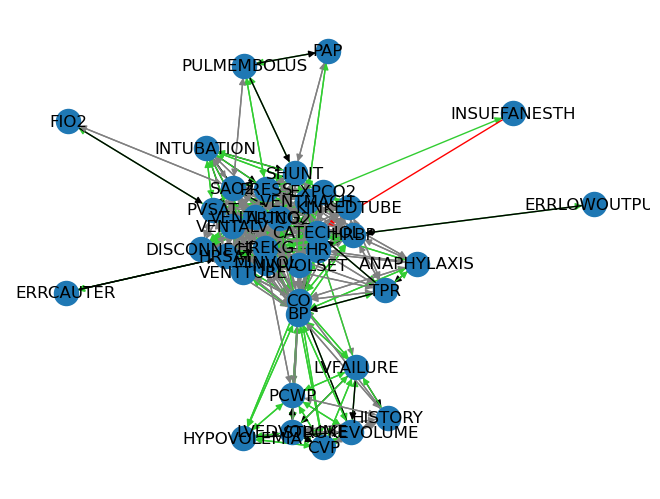

In [4]:
algtime = time.process_time()
key = {node_list[i]:i for i in range(len(node_list))}
fish_vals = [independence_tests.CITest.fisherz_test(a,key[x],key[y],[])[2] for x,y in it.permutations(node_list,2)]
fish_vars = [(x,y) for x,y in it.permutations(node_list,2)]

unique_edges, unique_vals = (lambda x: (np.array(fish_vars)[x], np.array(fish_vals)[x]))(np.argsort(fish_vals))
unique_edges, unique_vals = np.flip(unique_edges,axis=0), np.flip(unique_vals,axis=0)

m = binary_search(node_list, unique_edges)
thres = unique_vals[m]

DAG_w1 = nx.DiGraph()
DAG_w1.add_edges_from(unique_edges[m:])

DAG_w2 = triangulation_fisher(a, node_list, unique_edges[m:], thres)
algtime = time.process_time() - algtime

print("T(s)",algtime,algtime/pc_time)

FN = len(DAGt.edges-DAG_w2.edges) #False Negatives
FP = len(DAG_w2.edges-DAGt.edges) #False Positives
TP = len(DAGt.edges) - FN #True Positives = P - FN
TN = (n_nodes*n_nodes - len(DAGt.edges))-FP #True Negatives = N-FP

print("FPR", FP/(n_nodes*n_nodes - len(DAGt.edges)) ) #FPR = FP/N
print("FNR", FN/len(DAGt.edges) ) #FNR = FN/P
print("MCC", (TP*TN - FP*FN)/np.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN)) ) #MCC

G = nx.DiGraph()
G.add_edges_from(DAG_w2.edges,color="k")

were_removed = DAG_w1.edges - DAG_w2.edges #excess removed in 1st step
to_remove = G.edges() - DAGt.edges()
G.remove_edges_from( to_remove )
G.add_edges_from( to_remove ,color="limegreen") #excess
G.add_edges_from( were_removed ,color="gray") #excess removed
G.add_edges_from(list(DAGt.edges() - G.edges()) ,color="r") #missing

colors = [G[u][v]['color'] for u,v in G.edges()]
#pl.figure(figsize=(20,16))
nx.draw(G,edge_color=colors,with_labels=True)

T(s) 59.85668142999998 0.2384725979535158
FPR 0.1338709677419355
FNR 0.021739130434782608
MCC 0.5434025459095386


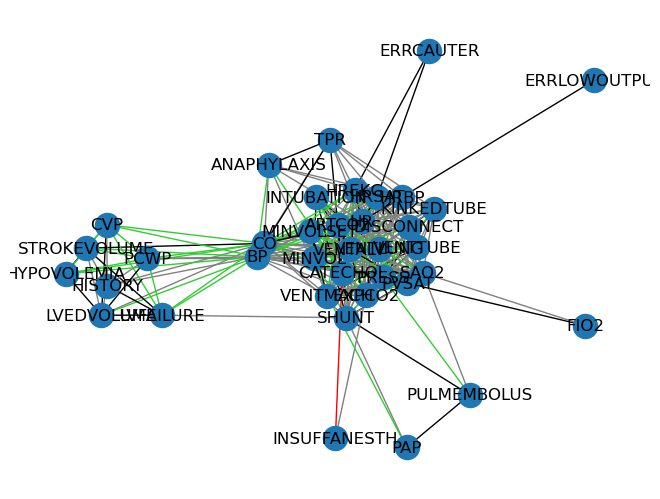

In [6]:
algtime = time.process_time()
key = {node_list[i]:i for i in range(len(node_list))}
fish_vals = [independence_tests.CITest.fisherz_test(a,key[x],key[y],[])[2] for x,y in it.combinations(node_list,2)]
fish_vars = [(x,y) for x,y in it.combinations(node_list,2)]

unique_edges, unique_vals = (lambda x: (np.array(fish_vars)[x], np.array(fish_vals)[x]))(np.argsort(fish_vals))
unique_edges, unique_vals = np.flip(unique_edges,axis=0), np.flip(unique_vals,axis=0)

m = binary_search(node_list, unique_edges)
thres = unique_vals[m]

DAG_w1 = nx.Graph()
DAG_w1.add_edges_from(unique_edges[m:])

DAG_w2 = triangulation_fisher_und(a, node_list, unique_edges[m:], thres)
algtime = time.process_time() - algtime

print("T(s)",algtime,algtime/pc_skeletime)

FN = len(Gt.edges-DAG_w2.edges) #False Negatives
FP = len(DAG_w2.edges-Gt.edges) #False Positives
TP = len(Gt.edges) - FN #True Positives = P - FN
TN = (int(n_nodes*(n_nodes-1)/2) - len(Gt.edges)) - FP #True Negatives = N - FP

print("FPR", FP/(n_nodes*(n_nodes-1)/2 - len(Gt.edges)) ) #FPR = FP/N
print("FNR", FN/len(Gt.edges) ) #FNR = FN/P
print("MCC", (TP*TN - FP*FN)/np.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN)) ) #MCC

G = nx.Graph()
G.add_edges_from(DAG_w2.edges,color="k")

were_removed = DAG_w1.edges - DAG_w2.edges #excess removed in 1st step
to_remove = G.edges() - Gt.edges()
G.remove_edges_from( to_remove )
G.add_edges_from( to_remove ,color="limegreen") #excess
G.add_edges_from( were_removed ,color="gray") #excess removed
G.add_edges_from(list(Gt.edges() - G.edges()) ,color="r") #missing

colors = [G[u][v]['color'] for u,v in G.edges()]
#pl.figure(figsize=(20,16))
nx.draw(G,edge_color=colors,with_labels=True)

## FisherKnee

T(s) 21.18125533600005 0.034427203593708246
FPR 0.06424792139077853
FNR 0.6739130434782609
MCC 0.18132697598741235


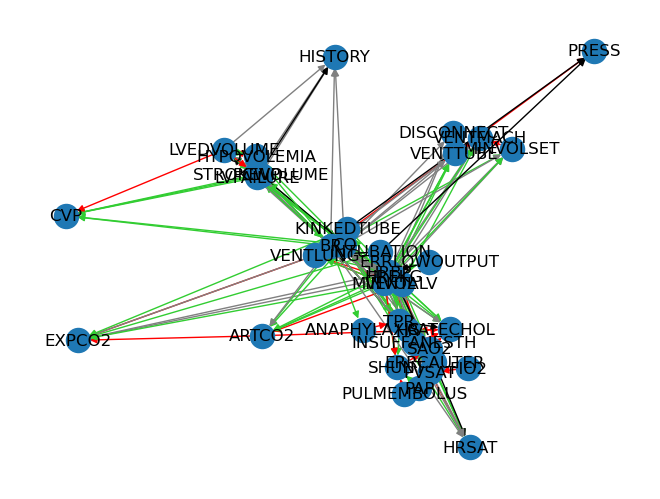

In [7]:
algtime = time.process_time()
key = {node_list[i]:i for i in range(len(node_list))}
fish_vals = [independence_tests.CITest.fisherz_test(a,key[x],key[y],[])[2] for x,y in it.permutations(node_list,2)]
fish_vars = [(x,y) for x,y in it.permutations(node_list,2)]

unique_edges, unique_vals = (lambda x: (np.array(fish_vars)[x], np.array(fish_vals)[x]))(np.argsort(fish_vals))
unique_edges, unique_vals = np.flip(unique_edges,axis=0), np.flip(unique_vals,axis=0)

gcc_nodes=np.zeros(len(unique_edges))
for j in range(len(unique_edges)):
    H = nx.Graph()
    H.add_edges_from(unique_edges[j:])
    gcc_nodes[j] = len(max(nx.connected_components(H),key=len))
del H
m = kneedle.auto_knee(np.column_stack((np.arange(len(gcc_nodes)),gcc_nodes)))
thres = unique_vals[m]

DAG_w1 = nx.DiGraph()
DAG_w1.add_edges_from(unique_edges[m:])

DAG_w2 = triangulation_fisher(a, node_list, unique_edges[m:], thres)
algtime = time.process_time() - algtime

print("T(s)",algtime,algtime/pc_time)

FN = len(DAGt.edges-DAG_w2.edges) #False Negatives
FP = len(DAG_w2.edges-DAGt.edges) #False Positives
TP = len(DAGt.edges) - FN #True Positives = P - FN
TN = (n_nodes*n_nodes - len(DAGt.edges)) - FP #True Negatives = N - FP

print("FPR", FP/(n_nodes*n_nodes - len(DAGt.edges)) ) #FPR = FP/N
print("FNR", FN/len(DAGt.edges) ) #FNR = FN/P
print("MCC", (TP*TN - FP*FN)/np.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN)) ) #MCC

G = nx.DiGraph()
G.add_edges_from(DAG_w2.edges,color="k")

were_removed = DAG_w1.edges - DAG_w2.edges #excess removed in 1st step
to_remove = G.edges() - DAGt.edges()
G.remove_edges_from( to_remove )
G.add_edges_from( to_remove ,color="limegreen") #excess
G.add_edges_from( were_removed ,color="gray") #excess removed
G.add_edges_from(list(DAGt.edges() - G.edges()) ,color="r") #missing

colors = [G[u][v]['color'] for u,v in G.edges()]
#pl.figure(figsize=(20,16))
nx.draw(G,edge_color=colors,with_labels=True)

T(s) 25.302847377000035 0.10080805693631825
FPR 0.06577916992952232
FNR 0.30434782608695654
MCC 0.5078388566155464


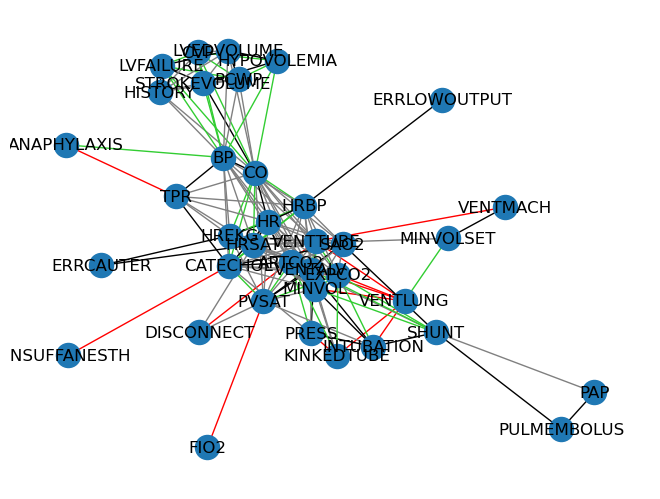

In [9]:
algtime = time.process_time()
key = {node_list[i]:i for i in range(len(node_list))}
fish_vals = [independence_tests.CITest.fisherz_test(a,key[x],key[y],[])[2] for x,y in it.combinations(node_list,2)]
fish_vars = [(x,y) for x,y in it.combinations(node_list,2)]

unique_edges, unique_vals = (lambda x: (np.array(fish_vars)[x], np.array(fish_vals)[x]))(np.argsort(fish_vals))
unique_edges, unique_vals = np.flip(unique_edges,axis=0), np.flip(unique_vals,axis=0)

gcc_nodes=np.zeros(len(unique_edges))
for j in range(len(unique_edges)):
    H = nx.Graph()
    H.add_edges_from(unique_edges[j:])
    gcc_nodes[j] = len(max(nx.connected_components(H),key=len))
del H
m = kneedle.auto_knee(np.column_stack((np.arange(len(gcc_nodes)),gcc_nodes)))
thres = unique_vals[m]

DAG_w1 = nx.Graph()
DAG_w1.add_edges_from(unique_edges[m:])

DAG_w2 = triangulation_fisher_und(a, node_list, unique_edges[m:], thres)
algtime = time.process_time() - algtime

print("T(s)",algtime,algtime/pc_skeletime)

FN = len(Gt.edges-DAG_w2.edges) #False Negatives
FP = len(DAG_w2.edges-Gt.edges) #False Positives
TP = len(Gt.edges) - FN #True Positives = P - FN
TN = (int(n_nodes*(n_nodes)/2) - len(Gt.edges)) - FP #True Negatives = N - FP

print("FPR", FP/(n_nodes*(n_nodes)/2 - len(Gt.edges)) ) #FPR = FP/N
print("FNR", FN/len(Gt.edges) ) #FNR = FN/P
print("MCC", (TP*TN - FP*FN)/np.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN)) ) #MCC

G = nx.Graph()
G.add_edges_from(DAG_w2.edges,color="k")

were_removed = DAG_w1.edges - DAG_w2.edges #excess removed in 1st step
to_remove = G.edges() - Gt.edges()
G.remove_edges_from( to_remove )
G.add_edges_from( to_remove ,color="limegreen") #excess
G.add_edges_from( were_removed ,color="gray") #excess removed
G.add_edges_from(list(Gt.edges() - G.edges()) ,color="r") #missing

colors = [G[u][v]['color'] for u,v in G.edges()]
#pl.figure(figsize=(20,16))
nx.draw(G,edge_color=colors,with_labels=True)

## NIConnected

In [ ]:
algtime = time.process_time()
weight_num_writer(X, states)
wn_var = np.array(weight_var_importer('weights_num.txt'))
wn_val = np.array(weight_val_importer('weights_num.txt'))

unique_edges = np.unique(wn_var[:,:2],axis=0)
unique_vals = np.zeros(len(unique_edges))
for j in range(len(unique_edges)):
    pair = unique_edges[j]
    unique_vals[j] = (np.max( np.abs( wn_val[np.all(wn_var[:,:2]==pair,axis=1)]) ) )
unique_vals=np.abs(unique_vals)

unique_edges, unique_vals = (lambda x: (unique_edges[x], unique_vals[x]))(np.argsort(unique_vals))

m = binary_search(list(states), unique_edges)
thres = unique_vals[m]

DAG_w2 = triangulation(X, node_list, unique_edges[m:], thres, states)
algtime = time.process_time() - algtime

print("T(s)",algtime,algtime/pc_time)

FN = len(DAGt.edges-DAG_w2.edges) #False Negatives
FP = len(DAG_w2.edges-DAGt.edges) #False Positives
TP = len(DAGt.edges) - FN #True Positives = P - FN
TN = (n_nodes*n_nodes - len(DAGt.edges)) - FP #True Negatives = N - FP

print("FPR", FP/(n_nodes*n_nodes - len(DAGt.edges)) ) #FPR = FP/N
print("FNR", FN/len(DAGt.edges) ) #FNR = FN/P
print("MCC", (TP*TN - FP*FN)/np.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN)) ) #MCC

G = nx.DiGraph()
G.add_edges_from(DAG_w2.edges,color="k")

to_remove = G.edges() - DAGt.edges()
G.remove_edges_from( to_remove )
G.add_edges_from( to_remove ,color="limegreen") #excess
G.add_edges_from(list(DAGt.edges() - G.edges()) ,color="r") #missing

colors = [G[u][v]['color'] for u,v in G.edges()]
#pl.figure(figsize=(20,16))
nx.draw(G,pos=pos,edge_color=colors,with_labels=True)

In [ ]:
algtime = time.process_time()
weight_num_writer(X, states)
wn_var = np.array(weight_var_importer('weights_num.txt'))
wn_val = np.array(weight_val_importer('weights_num.txt'))

unique_edges = np.unique(wn_var[:,:2],axis=0)
unique_vals = np.zeros(len(unique_edges))
for j in range(len(unique_edges)): #for a given direction, keep the biggest state
    pair = unique_edges[j]
    unique_vals[j] = (np.max( np.abs( wn_val[np.all(wn_var[:,:2]==pair,axis=1)]) ) )
unique_vals=np.abs(unique_vals)
#'''
for j in range(len(unique_edges)): #keep the biggest direction
    pair = unique_edges[j]
    anti_j = np.where(np.all(unique_edges==np.flip(pair),axis=1))[0][0]

    if unique_vals[j] >= unique_vals[anti_j]:
        
        unique_vals[anti_j] = -np.infty
unique_vals, unique_edges = (lambda x: (np.delete(unique_vals,x), np.delete(unique_edges,x,axis=0)))(np.where(unique_vals<0))
#'''
unique_edges, unique_vals = (lambda x: (unique_edges[x], unique_vals[x]))(np.argsort(unique_vals))

m = binary_search(list(states), unique_edges)
thres = unique_vals[m]

DAG_w2 = triangulation_und(X, node_list, unique_edges[m:], thres, states)
algtime = time.process_time() - algtime

print("T(s)",algtime,algtime/pc_skeletime)

FN = len(Gt.edges-DAG_w2.edges) #False Negatives
FP = len(DAG_w2.edges-Gt.edges) #False Positives
TP = len(Gt.edges) - FN #True Positives = P - FN
TN = (n_nodes*(n_nodes-1)/2 - len(Gt.edges)) - FP #True Negatives = N - FP

print("FPR", FP/(n_nodes*(n_nodes-1)/2 - len(Gt.edges)) ) #FPR = FP/N
print("FNR", FN/len(Gt.edges) ) #FNR = FN/P
print("MCC", (TP*TN - FP*FN)/np.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN)) ) #MCC

G = nx.Graph()
G.add_edges_from(DAG_w2.edges,color="k")

to_remove = G.edges() - Gt.edges()
G.remove_edges_from( to_remove )
G.add_edges_from( to_remove ,color="limegreen") #excess
G.add_edges_from(list(Gt.edges() - G.edges()) ,color="r") #missing

colors = [G[u][v]['color'] for u,v in G.edges()]
#pl.figure(figsize=(20,16))
nx.draw(G,pos=pos,edge_color=colors,with_labels=True)

## NIKnee

In [ ]:
algtime = time.process_time()
weight_num_writer(X, states)
wn_var = np.array(weight_var_importer('weights_num.txt'))
wn_val = np.array(weight_val_importer('weights_num.txt'))
    
unique_edges = np.unique(wn_var[:,:2],axis=0)
unique_vals = np.zeros(len(unique_edges))
for j in range(len(unique_edges)):
    pair = unique_edges[j]
    unique_vals[j] = (np.max( np.abs( wn_val[np.all(wn_var[:,:2]==pair,axis=1)]) ) )
unique_vals=np.abs(unique_vals)

unique_edges, unique_vals = (lambda x: (unique_edges[x], unique_vals[x]))(np.argsort(unique_vals))

##Threshold in first step
gcc_nodes=np.zeros(len(unique_edges))
for j in range(len(unique_edges)):
    H = nx.Graph()
    H.add_edges_from(unique_edges[j:])
    gcc_nodes[j] = len(max(nx.connected_components(H),key=len))
del H
m = kneedle.auto_knee(np.column_stack((np.arange(len(gcc_nodes)),gcc_nodes)))
thres = unique_vals[m]

DAG_w2 = triangulation(X, node_list, unique_edges[m:], thres, states)
algtime = time.process_time() - algtime

print("T(s)",algtime,algtime/pc_time)

FN = len(DAGt.edges-DAG_w2.edges) #False Negatives
FP = len(DAG_w2.edges-DAGt.edges) #False Positives
TP = len(DAGt.edges) - FN #True Positives = P - FN
TN = (n_nodes*n_nodes - len(DAGt.edges)) - FP #True Negatives = N - FP

print("FPR", FP/(n_nodes*n_nodes - len(DAGt.edges)) ) #FPR = FP/N
print("FNR", FN/len(DAGt.edges) ) #FNR = FN/P
print("MCC", (TP*TN - FP*FN)/np.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN)) ) #MCC

G = nx.DiGraph()
G.add_edges_from(DAG_w2.edges,color="k")

to_remove = G.edges() - DAGt.edges()
G.remove_edges_from( to_remove )
G.add_edges_from( to_remove ,color="limegreen") #excess
G.add_edges_from(list(DAGt.edges() - G.edges()) ,color="r") #missing

colors = [G[u][v]['color'] for u,v in G.edges()]
#pl.figure(figsize=(20,16))
nx.draw(G,edge_color=colors,with_labels=True)

In [ ]:
algtime = time.process_time()
weight_num_writer(X, states)
wn_var = np.array(weight_var_importer('weights_num.txt'))
wn_val = np.array(weight_val_importer('weights_num.txt'))

unique_edges = np.unique(wn_var[:,:2],axis=0)
unique_vals = np.zeros(len(unique_edges))
for j in range(len(unique_edges)): #for a given direction, keep the biggest state
    pair = unique_edges[j]
    unique_vals[j] = (np.max( np.abs( wn_val[np.all(wn_var[:,:2]==pair,axis=1)]) ) )
unique_vals=np.abs(unique_vals)
#'''
for j in range(len(unique_edges)): #keep the biggest direction
    pair = unique_edges[j]
    anti_j = np.where(np.all(unique_edges==np.flip(pair),axis=1))[0][0]

    if unique_vals[j] >= unique_vals[anti_j]:
        
        unique_vals[anti_j] = -np.infty
unique_vals, unique_edges = (lambda x: (np.delete(unique_vals,x), np.delete(unique_edges,x,axis=0)))(np.where(unique_vals<0))
#'''
unique_edges, unique_vals = (lambda x: (unique_edges[x], unique_vals[x]))(np.argsort(unique_vals))

gcc_nodes=np.zeros(len(unique_edges))
for j in range(len(unique_edges)):
    H = nx.Graph()
    H.add_edges_from(unique_edges[j:])
    gcc_nodes[j] = len(max(nx.connected_components(H),key=len))
del H
m = kneedle.auto_knee(np.column_stack((np.arange(len(gcc_nodes)),gcc_nodes)))
thres = unique_vals[m]

DAG_w2 = triangulation_und(X, node_list, unique_edges[m:], thres, states)
algtime = time.process_time() - algtime

print("T(s)",algtime,algtime/pc_skeletime)

FN = len(Gt.edges-DAG_w2.edges) #False Negatives
FP = len(DAG_w2.edges-Gt.edges) #False Positives
TP = len(Gt.edges) - FN #True Positives = P - FN
TN = (n_nodes*(n_nodes-1)/2 - len(Gt.edges)) - FP #True Negatives = N - FP

print("FPR", FP/(n_nodes*(n_nodes-1)/2 - len(Gt.edges)) ) #FPR = FP/N
print("FNR", FN/len(Gt.edges) ) #FNR = FN/P
print("MCC", (TP*TN - FP*FN)/np.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN)) ) #MCC

G = nx.Graph()
G.add_edges_from(DAG_w2.edges,color="k")

to_remove = G.edges() - Gt.edges()
G.remove_edges_from( to_remove )
G.add_edges_from( to_remove ,color="limegreen") #excess
G.add_edges_from(list(Gt.edges() - G.edges()) ,color="r") #missing

colors = [G[u][v]['color'] for u,v in G.edges()]
#pl.figure(figsize=(20,16))
nx.draw(G,pos=pos,edge_color=colors,with_labels=True)